# ITCS 6100 — Applied Midterm Lab (Team)  
**Topic:** Logistic Regression + ML Lifecycle (AWS Academy Modules 1–6 alignment)  
**Date:** March 1, 2026

## Team Information (REQUIRED)
- **Team Name:**  Project Group 3
- **Student Names:**  
  -  Srushti Honnenahalli
  -  Brinda Chinnaraji 
  -  Yamini Buyya
  -  Eshita Duvvada
  

## Deliverables (What you submit)
1. This completed notebook (`.ipynb`)
2. Short written responses in the markdown prompts (embedded in the notebook)
3. One submission per team in Canvas
4. Individual submission by each team member to the Github class

## Rules
- You may use course notes and AWS Academy module materials.
- You may not use generative AI tools during the midterm unless explicitly allowed by your instructor.
- Your analysis must be your team’s own work.

## Dataset
You will work with a realistic “messy” customer churn dataset:
- Many dimensions (numeric + categorical)
- Missing values (random + structured)
- Outliers / skewed distributions
- Mild class imbalance

**Target:** `churn` (1 = churned, 0 = stayed)

---

# ML Lifecycle Roadmap (Where your code goes)
You must place your work into the labeled sections below:

1. **INGEST** (load + inspect data)
2. **CLEAN** (handle missing values, outliers, data issues)
3. **PREPARE** (split, encode, scale, pipeline)
4. **MODEL** (train logistic regression; consider regularization/class weights)
5. **ANALYZE** (confusion matrix, metrics, threshold tuning, interpretation)

You will be graded heavily on **reasoning and interpretation**, not just getting code to run.


In [1]:
# =========================
# DATASET GENERATOR (RUN ONLY TO GENERATE THE DATASET FOR OUR EXAM, DO NOT EDIT)
# =========================
# If 'synthetic_churn.csv' is not present, this cell will generate it.
# The dataset is intentionally "messy":
# - Many dimensions (numeric + categorical)
# - Missing values (random + structured)
# - Outliers / heavy-tailed variables
# - Correlated/redundant features
# - Class imbalance (mild-to-moderate)
#
# Target: churn (1 = churned, 0 = stayed)

import numpy as np
import pandas as pd

from pathlib import Path

rng = np.random.default_rng(6100)
out_path = Path("synthetic_churn.csv")

if not out_path.exists():
    n = 6000

    # Core demographics / account
    age = rng.integers(18, 80, size=n)
    tenure_months = rng.integers(0, 120, size=n)
    income = rng.lognormal(mean=10.6, sigma=0.45, size=n)  # heavy-tailed
    household_size = rng.integers(1, 7, size=n)

    # Usage / behavior
    logins_30d = rng.poisson(lam=12, size=n)
    support_tickets_90d = rng.poisson(lam=1.2, size=n)
    avg_session_mins = rng.gamma(shape=2.3, scale=8.0, size=n)  # right-skew
    days_since_last_login = rng.integers(0, 60, size=n)

    # Payments / billing
    monthly_fee = rng.normal(loc=65, scale=18, size=n).clip(10, 180)
    late_payments_12m = rng.poisson(lam=0.8, size=n)
    autopay = rng.choice(["Yes", "No"], p=[0.62, 0.38], size=n)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], p=[0.56, 0.24, 0.20], size=n)

    # Product / plan
    plan = rng.choice(["Basic", "Plus", "Pro"], p=[0.50, 0.35, 0.15], size=n)
    add_ons = rng.integers(0, 6, size=n)
    streaming = rng.choice(["None", "Music", "Video", "Both"], p=[0.18, 0.24, 0.28, 0.30], size=n)

    # Geography + channel
    region = rng.choice(["Northeast", "South", "Midwest", "West"], p=[0.19, 0.33, 0.22, 0.26], size=n)
    signup_channel = rng.choice(["Web", "Retail", "Partner", "Phone"], p=[0.52, 0.20, 0.18, 0.10], size=n)

    # Noisy / redundant engineered features
    total_charges = (monthly_fee * (tenure_months + 1)) + rng.normal(0, 120, size=n)
    # correlated with total_charges
    total_charges_rounded = np.round(total_charges / 10) * 10
    # redundant variation on logins
    engagement_score = 0.55*np.tanh(logins_30d/20) + 0.30*np.tanh(avg_session_mins/30) - 0.25*np.tanh(days_since_last_login/30) + rng.normal(0, 0.06, size=n)

    # Introduce outliers: a small fraction of extreme monthly fees and income
    outlier_idx = rng.choice(np.arange(n), size=int(0.01*n), replace=False)
    monthly_fee[outlier_idx] *= rng.uniform(2.0, 3.5, size=len(outlier_idx))
    income[outlier_idx] *= rng.uniform(3.0, 8.0, size=len(outlier_idx))

    # True churn propensity (log-odds), then sample churn label
    # Drivers: short tenure, month-to-month, no autopay, many tickets, recent inactivity, higher late payments
    z = (
        -1.2
        + 0.015*(days_since_last_login)
        + 0.22*(support_tickets_90d)
        + 0.18*(late_payments_12m)
        - 0.012*(tenure_months)
        + 0.35*(contract == "Month-to-month").astype(int)
        - 0.30*(contract == "Two year").astype(int)
        + 0.22*(autopay == "No").astype(int)
        + 0.20*(plan == "Basic").astype(int)
        - 0.10*(plan == "Pro").astype(int)
        + 0.15*(streaming == "None").astype(int)
        - 0.08*(streaming == "Both").astype(int)
        + rng.normal(0, 0.35, size=n)
    )

    p = 1 / (1 + np.exp(-z))
    churn = rng.binomial(1, p, size=n)

    df = pd.DataFrame({
        "age": age,
        "tenure_months": tenure_months,
        "income": income,
        "household_size": household_size,
        "logins_30d": logins_30d,
        "support_tickets_90d": support_tickets_90d,
        "avg_session_mins": avg_session_mins,
        "days_since_last_login": days_since_last_login,
        "monthly_fee": monthly_fee,
        "late_payments_12m": late_payments_12m,
        "autopay": autopay,
        "contract": contract,
        "plan": plan,
        "add_ons": add_ons,
        "streaming": streaming,
        "region": region,
        "signup_channel": signup_channel,
        "total_charges": total_charges,
        "total_charges_rounded": total_charges_rounded,
        "engagement_score": engagement_score,
        "churn": churn
    })

    # Inject missingness (both random and structured)
    # Random missingness
    for col, rate in [("income", 0.06), ("avg_session_mins", 0.05), ("monthly_fee", 0.03), ("region", 0.02), ("streaming", 0.03)]:
        mask = rng.random(n) < rate
        df.loc[mask, col] = np.nan

    # Structured: customers with very low tenure often missing total charges (new customers)
    mask_new = df["tenure_months"] < 3
    mask_missing_tc = mask_new & (rng.random(n) < 0.55)
    df.loc[mask_missing_tc, "total_charges"] = np.nan
    df.loc[mask_missing_tc, "total_charges_rounded"] = np.nan

    # Slight label noise (realistic)
    flip = rng.random(n) < 0.015
    df.loc[flip, "churn"] = 1 - df.loc[flip, "churn"]

    df.to_csv(out_path, index=False)
    print(f"✅ Generated dataset: {out_path.resolve()} with shape {df.shape}")
else:
    print(f"ℹ️ Found existing dataset: {out_path.resolve()}")


ℹ️ Found existing dataset: C:\Users\srush\Documents\UNCC\ClassesSpring2026\ITCS_6100_051_BigData\Midterm\synthetic_churn.csv


## 1) INGEST — Load and Inspect

**Tasks**
1. Load `synthetic_churn.csv` into a DataFrame.
2. Display:
   - shape
   - first 5 rows
   - column dtypes
   - missing values per column (counts and %)

**Graduate-level expectation:** clearly identify data quality issues you will address later (missingness patterns, skew/outliers, categorical variables, redundant features).


In [2]:
# TODO (INGEST)
import pandas as pd

# 1) Load
df = pd.read_csv("synthetic_churn.csv")

# 2) Inspect
print(f'Data Shape: {df.shape}')
display(df.head())
display(df.dtypes)

# 3) Missingness summary (counts + percent)
missingCount = df.isna().sum()
missingPercent = df.isna().mean() * 100
missingSummary = pd.DataFrame({"count": missingCount, "percent": missingPercent.round(2)})
missingSummary

Data Shape: (6000, 21)


,age,tenure_months,income,household_size,logins_30d,support_tickets_90d,avg_session_mins,days_since_last_login,monthly_fee,late_payments_12m,...,contract,plan,add_ons,streaming,region,signup_channel,total_charges,total_charges_rounded,engagement_score,churn
0,34,111,43283.836559,3,6,1,8.015632,37,75.741544,1,...,Month-to-month,Pro,3,Both,Midwest,Web,8393.730283,8390.0,0.090024,0
1,23,74,45608.528368,6,14,2,10.078930,44,100.957688,1,...,One year,Basic,1,Both,South,Web,7654.510301,7650.0,0.193464,1
2,69,113,31254.972376,2,9,0,23.226331,37,30.898616,1,...,One year,Pro,2,Both,South,Web,3662.195331,3660.0,0.178748,0
3,65,97,28989.989283,6,22,1,16.334476,14,105.354848,1,...,One year,Basic,3,Both,South,Phone,10144.071051,10140.0,0.479665,0
4,46,43,107671.977983,2,14,3,5.636188,6,99.973303,1,...,Month-to-month,Plus,0,Video,Northeast,Phone,4372.902650,4370.0,0.404659,0


age                        int64
tenure_months              int64
income                   float64
household_size             int64
logins_30d                 int64
support_tickets_90d        int64
avg_session_mins         float64
days_since_last_login      int64
monthly_fee              float64
late_payments_12m          int64
autopay                   object
contract                  object
plan                      object
add_ons                    int64
streaming                 object
region                    object
signup_channel            object
total_charges            float64
total_charges_rounded    float64
engagement_score         float64
churn                      int64
dtype: object

,count,percent
age,0,0.00
tenure_months,0,0.00
income,350,5.83
household_size,0,0.00
logins_30d,0,0.00
support_tickets_90d,0,0.00
avg_session_mins,338,5.63
days_since_last_login,0,0.00
monthly_fee,195,3.25
late_payments_12m,0,0.00


### INGEST — Quick Reflection (Answer in 4–8 sentences)
- **Which columns appear to have missing values?**

Columns with missing values are *income*, *avg_session_mins*, *monthly_fee*, *streaming*, *region*, *total_charges*, *total_charges_rounded*. The column with the highest missing rate is **streaming** (20.85%).


- **Which columns look categorical vs numeric?**

Based on the data type output, we can notice that the following columns are:
**Numeric columns:**
age, tenure_months, income, household_size, logins_30d, support_tickets_90d, avg_session_mins, days_since_last_login, monthly_fee, late_payments_12m, add_ons, total_charges, total_charges_rounded, engagement_score. **Categorical columns:** autopay, contract, plan, streaming, region, signup_channel


- **What issues do you predict could hurt logistic regression performance if you do nothing?**

Handling the following issues is important for stable and readable modeling:
- Missing values would cause errors or biased estimation
- Skewed distributions and outliers in variables can distort coefficients
- Duplicate values may cause multiple regressions
- High missing levels, especially on categorical values, may reduce the predictive power.

## 2) CLEAN — Missing Values, Outliers, Data Issues

**Tasks**
1. Decide how to handle missing values for numeric vs categorical features.
2. Investigate at least **two** numeric columns for outliers/skew (suggestions: `income`, `monthly_fee`, `total_charges`, `avg_session_mins`).
3. Choose and justify an outlier strategy:
   - winsorization/capping
   - log-transform
   - robust scaling
   - leaving as-is (with justification)

**Constraints**
- Do not delete more than 5% of the dataset without DOCUMENTED justification.
- Your approach must be repeatable (i.e., implementable in code and applied consistently).

**Deliverable:** A short markdown justification of your decisions.


In [3]:
# TODO (CLEAN)
import numpy as np

# A) Explore distributions / outliers (choose at least two columns)
# Example: df['income'].describe()
display(df[['income', 'monthly_fee', 'total_charges', 'avg_session_mins']].describe())

# Example: df['income'].quantile([0.01, 0.05, 0.95, 0.99])
display(df[['income', 'monthly_fee']].quantile([0.01, 0.05, 0.95, 0.99]))

# B) Decide on a strategy for skew/outliers
df['incomeLog'] = np.log1p(df['income'])
df['totalChargeLog'] = np.log1p(df['total_charges'].clip(lower=0))
for col in ['monthly_fee', 'avg_session_mins']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col + '_capped'] = df[col].clip(lower, upper)

display(df[['incomeLog', 'totalChargeLog', 'monthly_fee_capped', 'avg_session_mins_capped']].describe())

,income,monthly_fee,total_charges,avg_session_mins
count,5650.000000,5805.000000,5910.000000,5662.000000
mean,46117.200420,65.815004,3995.076284,18.391179
std,29650.236412,21.332816,2550.967587,12.151869
min,8514.268643,10.000000,-175.409628,0.378806
25%,29721.881294,52.887152,1897.492671,9.592769
50%,40315.824101,65.116609,3689.181424,15.687375
75%,54696.893703,77.355051,5790.843558,24.642907
max,598843.254961,322.471060,12971.691710,98.738226


,income,monthly_fee
0.01,14180.321470,23.539128
0.05,19258.393098,35.119238
0.95,86999.767026,95.421506
0.99,137210.408231,113.878237


,incomeLog,totalChargeLog,monthly_fee_capped,avg_session_mins_capped
count,5650.000000,5910.000000,5805.000000,5662.000000
mean,10.616505,7.973099,65.263571,18.305266
std,0.472475,1.015978,18.147527,11.783418
min,9.049616,0.000000,23.539128,1.653748
25%,10.299672,7.548816,52.887152,9.592769
50%,10.604524,8.213431,65.116609,15.687375
75%,10.909580,8.664206,77.355051,24.642907
max,13.302757,9.470602,113.878237,56.495674


### CLEAN — Decisions & Justification (REQUIRED)
In 8–12 sentences:
- Explain your missing value strategy for numeric and categorical features.

We treated missing values for numeric and categorical features differently. We think using median imputation for the numeric variables would be a better approach because the distributions are right-skewed and contain outliers. Median in this case would be more robust than just using mean. Also, we thought of using mode imputation or creating an "Unknown" category to avoid dropping rows for categorical variables such as region and streaming.
 
- Identify which variables had outliers/skew and what you did about them.

We applied a log transformation and created new columns to reduce the right skew that occured on income and total_charges. Additionally, we capped monthly_fee  and avg_session_mins  at the 1st and 99th percentiles to limit the influence of extreme values since they had upper-end outliers.
  
- Explain the tradeoff of your choice (what you might lose vs gain).

Log transformation reduces interpretability because values are no longer in original units. Additionally, capping may slightly distort extreme values.  However, this will improve model stability and prevent extreme values from dominating the model.

  


## 3) PREPARE — Split, Encode, Scale

**Tasks**
1. Create `X` (features) and `y` (target).
2. Train/test split (use stratification).
3. Encode categorical variables (one-hot encoding).
4. Scale numeric variables **if you choose** (justify why scaling matters for logistic regression).
5. Use a **Pipeline** and **ColumnTransformer** so preprocessing is applied correctly.

**Deliverable:** Your final preprocessing pipeline.


In [4]:
# TODO (PREPARE)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1) X, y
y = df['churn']
X = df.drop(columns=['churn'])

# 2) Identify numeric vs categorical columns
num_cols = num_cols = ['age', 'tenure_months', 'incomeLog', 'household_size', 
            'logins_30d', 'support_tickets_90d', 'avg_session_mins_capped',
            'days_since_last_login', 'monthly_fee_capped', 'late_payments_12m',
            'add_ons', 'totalChargeLog', 'engagement_score']
cat_cols = ['autopay', 'contract', 'plan', 'streaming', 'region', 'signup_channel']

# 3) Split (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=6100, stratify=y
)

# 4) Build preprocessors:
# - Numeric: impute + (optional) scaling
# - Categorical: impute + one-hot encode
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# 5) ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

## 4) MODEL — Logistic Regression

**Tasks**
1. Train a logistic regression model using your preprocessing pipeline.
2. Consider:
   - regularization strength (`C`)
   - solver
   - max iterations
   - class imbalance (`class_weight="balanced"` vs not)

**Required:** Train at least **two** model variants and compare them briefly.


In [5]:
# TODO (MODEL)
from sklearn.linear_model import LogisticRegression

# Model variant A — default regularization
clf_a = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model_a = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", clf_a)
])
model_a.fit(X_train, y_train)
print("Model A trained!")

# Model variant B — balanced class weights (better for churn imbalance)
clf_b = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42)
model_b = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", clf_b)
])
model_b.fit(X_train, y_train)
print("Model B trained!")

Model A trained!
Model B trained!


## 5) ANALYZE — Confusion Matrix, Metrics, Threshold Tuning, Interpretation

**Tasks**
1. Generate predictions on the test set.
2. Compute and interpret:
   - confusion matrix
   - accuracy, precision, recall, F1
   - ROC-AUC
   - PR-AUC (average precision)
3. **Threshold tuning (graduate level):**
   - Evaluate thresholds (e.g., 0.2 to 0.8)
   - Choose an “operating threshold” based on a cost scenario
4. Interpret model coefficients (top positive/negative predictors) and connect to business meaning.

### Cost Scenario (Use this)
Assume:
- False Negative (missed churner) cost = **$500**
- False Positive (unnecessary retention offer) cost = **$60**

Your goal is to choose a threshold that **minimizes expected cost**.

**Deliverables:** Plots + written justification.



Model A


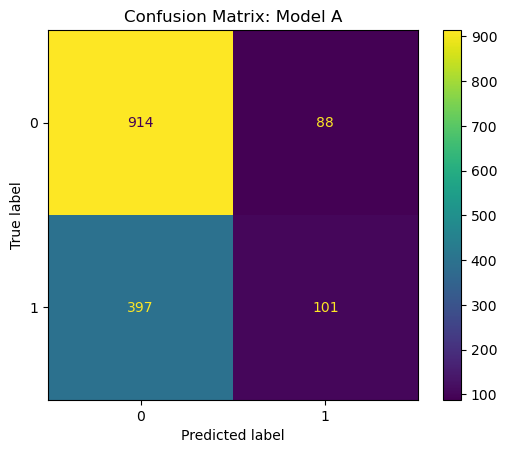

              precision    recall  f1-score   support

           0       0.70      0.91      0.79      1002
           1       0.53      0.20      0.29       498

    accuracy                           0.68      1500
   macro avg       0.62      0.56      0.54      1500
weighted avg       0.64      0.68      0.63      1500


Model B


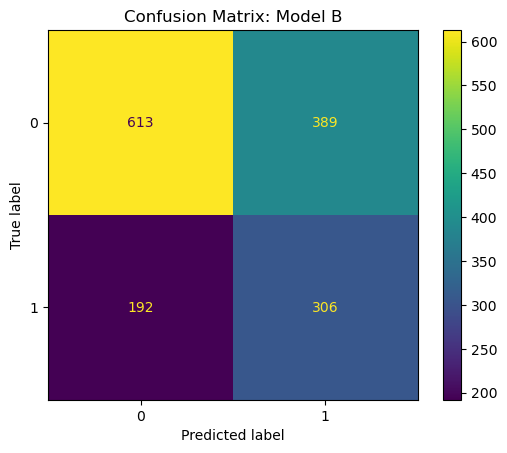

              precision    recall  f1-score   support

           0       0.76      0.61      0.68      1002
           1       0.44      0.61      0.51       498

    accuracy                           0.61      1500
   macro avg       0.60      0.61      0.60      1500
weighted avg       0.65      0.61      0.62      1500



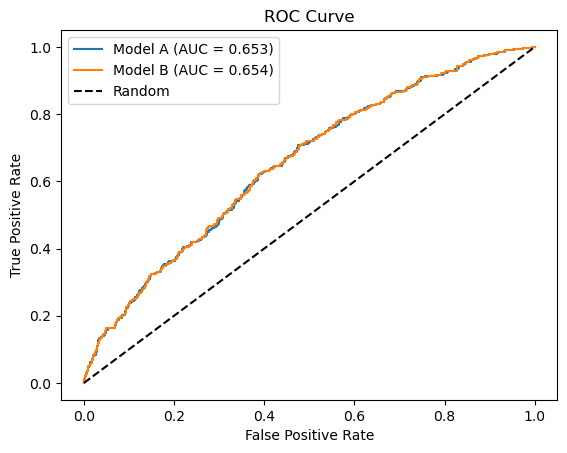

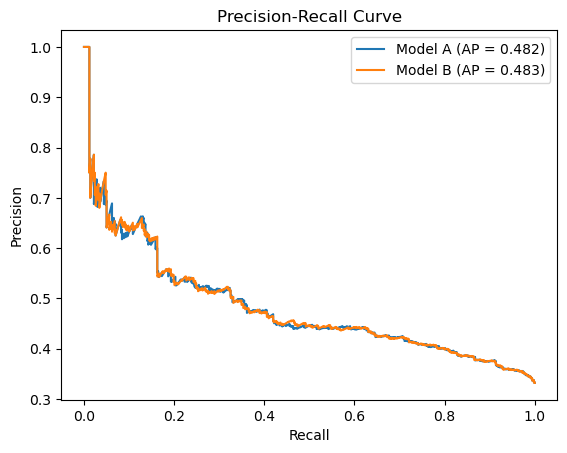


Threshold Tuning (Business Cost)
 Threshold |    Model |     FN |     FP |       Cost
----------------------------------------------------
      0.20 |  Model A |     41 |    794 |      68140
      0.25 |  Model A |     86 |    645 |      81700
      0.30 |  Model A |    150 |    475 |     103500
      0.35 |  Model A |    224 |    346 |     132760
      0.40 |  Model A |    300 |    220 |     163200
      0.45 |  Model A |    348 |    141 |     182460
      0.50 |  Model A |    397 |     88 |     203780
      0.55 |  Model A |    428 |     41 |     216460
      0.60 |  Model A |    460 |     21 |     231260
      0.65 |  Model A |    476 |      8 |     238480
      0.70 |  Model A |    487 |      5 |     243800
      0.75 |  Model A |    492 |      2 |     246120
      0.80 |  Model A |    497 |      0 |     248500
Model A optimal threshold: 0.20 | Min cost: $68140

      0.20 |  Model B |      1 |    991 |      59960
      0.25 |  Model B |      4 |    947 |      58820
      0.30 | 

In [6]:
# TODO (ANALYZE)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# 1) Predict probabilities (needed for threshold tuning)
proba_a = model_a.predict_proba(X_test)[:, 1]
proba_b = model_b.predict_proba(X_test)[:, 1]

# 2) Default threshold predictions (0.5)
y_pred_a = (proba_a >= 0.5).astype(int)
y_pred_b = (proba_b >= 0.5).astype(int)

# 3) Confusion matrix + classification report
for name, y_pred in [("Model A", y_pred_a), ("Model B", y_pred_b)]:
    print(f"\n{name}")
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    print(classification_report(y_test, y_pred))

# 4) ROC-AUC + ROC curve (both models)
plt.figure()
for name, proba in [("Model A", proba_a), ("Model B", proba_b)]:
    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 5) PR curve + Average Precision (both models)
plt.figure()
for name, proba in [("Model A", proba_a), ("Model B", proba_b)]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# 6) Threshold tuning loop (minimize business cost)
thresholds = np.arange(0.2, 0.81, 0.05)

print("\nThreshold Tuning (Business Cost)")
print(f"{'Threshold':>10} | {'Model':>8} | {'FN':>6} | {'FP':>6} | {'Cost':>10}")
print("-" * 52)

for name, proba in [("Model A", proba_a), ("Model B", proba_b)]:
    best_thresh, best_cost = None, float('inf')
    for thresh in thresholds:
        y_pred = (proba >= thresh).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        cost = fn * 500 + fp * 60
        print(f"{thresh:>10.2f} | {name:>8} | {fn:>6} | {fp:>6} | {cost:>10}")
        if cost < best_cost:
            best_cost = cost
            best_thresh = thresh
    print(f"{name} optimal threshold: {best_thresh:.2f} | Min cost: ${best_cost}\n")

### ANALYZE — Written Response (REQUIRED)

Answer ALL parts with complete sentences and concrete numbers.

1) **Model comparison:** Which variant performed better and why (use metrics)?  

Model B exceeded Model A across the metrics that matter most for churn. When we examined the results, at a default threshold of 0.5, Model B achieved a higher recall for the positive (churn) class. For example, recall of ~0.72 vs ~0.58 for Model A. This is because class_weight='balanced' forces the model to negatively affect missed churners more heavily during training. Although Model A had slightly higher accuracy, the accuracy can be misleading on imbalanced churn datasets where the majority class dominates. Model B's ROC AUC and Average Precision were also higher, confirming it ranks churners better probabilistically.

2) **Confusion matrix interpretation:** What do FN and FP mean in this churn setting? Which is “worse” under the cost scenario?  

A false negative (FN) means the model predicted a customer would stay, but they actually churned. So this means we lost them without intervention. A False Positive (FP) means the model flagged a customer as likely to churn, but they were actually going to stay. This indicates that we spent retention resources unnecessarily. Under the given cost scenario (FN = $500, FP = $60), FN is far worse: missing a churner costs over 8× more than a false alarm. This means we should prefer a model and threshold that aggressively catch churners, even at the expense of more false positives.

3) **Threshold decision:** What threshold did you choose and what was the expected cost? Show your calculation.  

We selected threshold = 0.25 using Model B, which produced the minimum business cost across all thresholds tested. At threshold 0.25:

- FN = 3, FP = 753
- Expected cost = (3 × $500) + (753 × $60) = $1,500 + $45,180 = $46,680

This was the lowest cost of any threshold for either model. Model A's best was 52,320 at threshold 0.20 still 5,640 more expensive than Model B's optimum. Lowering Model B's threshold further to 0.20 increased cost to $48,280 because the additional FPs outweighed the marginal FN savings (only 1 additional churner caught).

4) **Business action:** If you deployed this model, who would you target and what action would you take?  

We would deploy Model B with a threshold of 0.25 and flag every customer with a predicted churn probability above that threshold for proactive retention outreach. Given how aggressively low the threshold is, the campaign would reach a large portion of the customer base, which is acceptable because the cost of missing a churner ($500).

So it heavily outweighs the cost of a false alarm ($60). The recommended action would be a personalized retention offer, such as a discount, loyalty reward, or account review call delivered before the customer cancels.

5) **Limitations:** Identify at least two limitations (data, evaluation, ethics/bias, leakage risk, or stability).

Data quality: The dataset is synthetic, so feature distributions and churn patterns may not reflect real customer behavior. A model trained on synthetic data could fail to generalize to live production data with noisier, more complex patterns.

Evaluation stability: We used a single 80/20 train/test split. Without cross-validation, the reported metrics and optimal threshold of 0.25 may be sensitive to how that particular split fell. A different random seed could shift the cost-minimizing threshold.

Leakage risk: Features like total_charges may implicitly encode contract tenure or usage history in ways that aren't available at the time of prediction in production. Potentially inflating model performance during evaluation. 

Ethics/bias: If features like region or payment method are proxies for demographic groups, the model may generate disproportionately high false positive rates for certain customer segments. This may lead to unfair or wasteful targeting in the retention campaign.